
### NHS A&E Performance Analysis & Predictive Modelling
### Data: Quarter 4 2025/26 - A&E Attendances by Provider


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    ConfusionMatrixDisplay,
)
import warnings
warnings.filterwarnings("ignore")



### 1. LOAD & CLEAN DATA


In [10]:
# Update this path to wherever your CSV files are located
DATA_DIR = "./"

print("Loading data...")
df = pd.read_csv(DATA_DIR + "Provider_Level_Data.csv")
mapping = pd.read_csv(DATA_DIR + "System_Mapping.csv")

# Drop the national England summary row
df = df[df["Code"] != "-"].copy()
df.reset_index(drop=True, inplace=True)

# --- Rename columns for readability ---
col_map = {
    "A&E attendances - Type 1 Departments - Major A&E": "type1_attendances",
    "Type 2 Departments - Single Specialty":            "type2_attendances",
    "Type 3 Departments - Other A&E/Minor Injury Unit": "type3_attendances",
    "Total attendances":                                "total_attendances",
    "Total Attendances < 4 hours":                      "total_lt4h",
    "Total Attendances > 4 hours":                      "total_gt4h",
    "Percentage of attendances within 4 hours - Percentage in 4 hours or less (all)": "pct_within_4h_all",
    "Percentage in 4 hours or less (type 1)":           "pct_within_4h_t1",
    "Percentage in 4 hours or less (type 2)":           "pct_within_4h_t2",
    "Percentage in 4 hours or less (type 3)":           "pct_within_4h_t3",
    "Emergency Admissions - Emergency Admissions via Type 1 A&E": "emerg_admissions_t1",
    "Emergency Admissions via Type 2 A&E":              "emerg_admissions_t2",
    "Emergency Admissions via Type 3 and 4 A&E":        "emerg_admissions_t3",
    "Total Emergency Admissions via A&E":               "total_emerg_admissions_ae",
    "Other Emergency admissions (i.e not via A&E)":     "other_emerg_admissions",
    "Total Emergency Admissions":                       "total_emerg_admissions",
    "Number of patients spending >4 hours from decision to admit to admission":  "pts_gt4h_dta",
    "Number of patients spending >12 hours from decision to admit to admission": "pts_gt12h_dta",
}
df.rename(columns=col_map, inplace=True)

# Convert percentage columns (may contain "-" for missing values)
pct_cols = ["pct_within_4h_all", "pct_within_4h_t1", "pct_within_4h_t2", "pct_within_4h_t3"]
for col in pct_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"  Loaded {len(df)} provider records")
print(f"  Missing 4-hr performance values: {df['pct_within_4h_all'].isna().sum()}")

Loading data...
  Loaded 199 provider records
  Missing 4-hr performance values: 9



### 2. FEATURE ENGINEERING


In [11]:
print("\nEngineering features...")

safe_div = lambda a, b: a / b.replace(0, np.nan)

df["admission_rate"]   = safe_div(df["total_emerg_admissions"],  df["total_attendances"])
df["t1_share"]         = safe_div(df["type1_attendances"],        df["total_attendances"])
df["t2_share"]         = safe_div(df["type2_attendances"],        df["total_attendances"])
df["t3_share"]         = safe_div(df["type3_attendances"],        df["total_attendances"])
df["dta_4h_rate"]      = safe_div(df["pts_gt4h_dta"],             df["total_attendances"])
df["dta_12h_rate"]     = safe_div(df["pts_gt12h_dta"],            df["total_attendances"])
df["gt4h_rate"]        = safe_div(df["total_gt4h"],               df["total_attendances"])

# Region label-encode for modelling
le = LabelEncoder()
df["region_enc"] = le.fit_transform(df["Region"].fillna("Unknown"))

# Target: 1 = above national median 4-hr performance, 0 = below
median_perf = df["pct_within_4h_all"].median()
df["target"] = (df["pct_within_4h_all"] >= median_perf).astype(int)

print(f"  Median 4-hr performance: {median_perf:.2%}")
print(f"  Class balance  |  Above median: {df['target'].sum()}  |  Below: {(df['target']==0).sum()}")


Engineering features...
  Median 4-hr performance: 77.62%
  Class balance  |  Above median: 95  |  Below: 104


### 3. EXPLORATORY DATA ANALYSIS

In [12]:
print("\nRunning EDA...")

# --- (A) National summary ---
print("\n--- National summary ---")
summary = df["pct_within_4h_all"].describe()
print(summary.apply(lambda x: f"{x:.2%}" if isinstance(x, float) else x))

# --- (B) Regional breakdown ---
region_stats = (
    df.groupby("Region")
    .agg(
        providers=("Name", "count"),
        avg_4h_pct=("pct_within_4h_all", "mean"),
        total_attendances=("total_attendances", "sum"),
        avg_admission_rate=("admission_rate", "mean"),
        avg_dta_12h=("dta_12h_rate", "mean"),
    )
    .reset_index()
    .sort_values("avg_4h_pct", ascending=False)
)
print("\n--- Regional breakdown ---")
print(region_stats.to_string(index=False))

# --- (C) Top & bottom performers ---
perf_cols = ["Code", "Region", "Name", "total_attendances",
             "pct_within_4h_all", "admission_rate", "dta_12h_rate"]

print("\n--- Top 10 providers (4-hr performance) ---")
print(df.nlargest(10, "pct_within_4h_all")[perf_cols].to_string(index=False))

print("\n--- Bottom 10 providers (4-hr performance) ---")
print(df.nsmallest(10, "pct_within_4h_all")[perf_cols].to_string(index=False))


Running EDA...

--- National summary ---
count    19000.00%
mean        81.53%
std         14.30%
min         47.06%
25%         70.24%
50%         77.62%
75%         98.58%
max        100.00%
Name: pct_within_4h_all, dtype: object

--- Regional breakdown ---
                               Region  providers  avg_4h_pct  total_attendances  avg_admission_rate  avg_dta_12h
              NHS England South East          34    0.851871            1048051            0.159364     0.013130
                NHS England Midlands          43    0.846533            1269945            0.136904     0.018629
                   NHS England London         25    0.825034            1209072            0.116684     0.017317
NHS England North East And Yorkshire          30    0.800654            1079728            0.209377     0.010947
              NHS England South West          23    0.794356             601547            0.221550     0.017079
         NHS England East Of England          16    0.781773 

### 4. VISUALISATIONS



Generating plots...


Text(0.5, 91.7222222222222, 'Rate (%)')

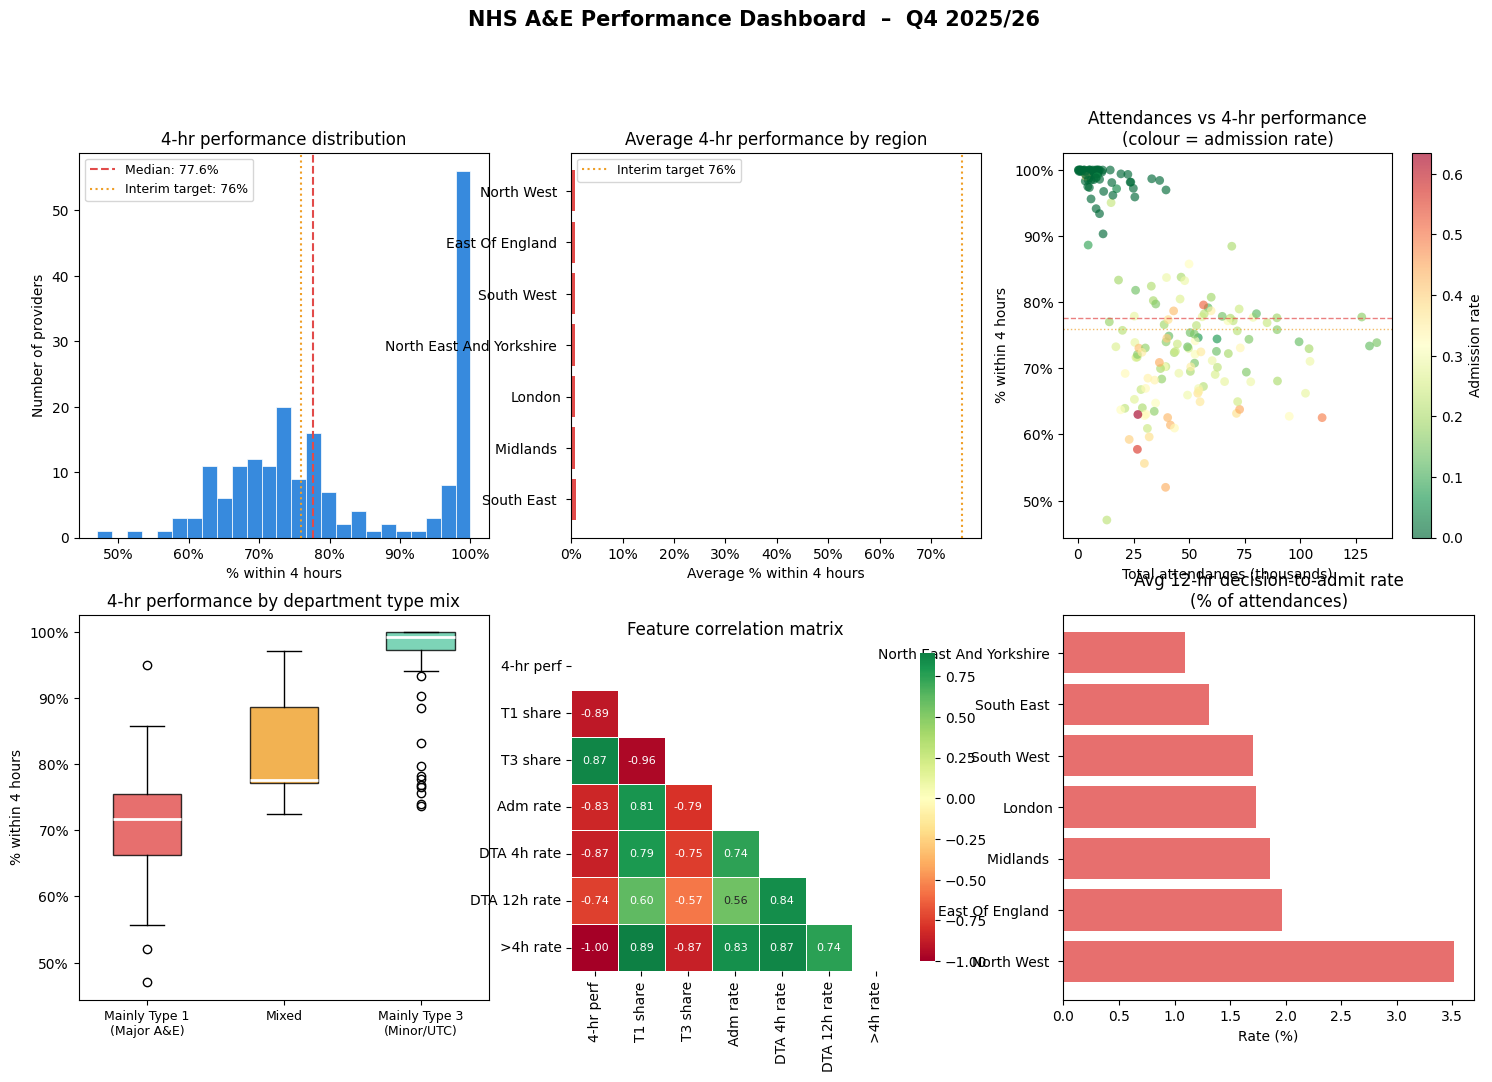

In [13]:
print("\nGenerating plots...")

palette_good   = "#5DCAA5"  # teal  – meets target
palette_warn   = "#EF9F27"  # amber – near target
palette_danger = "#E24B4A"  # red   – below target
palette_blue   = "#378ADD"  # blue  – neutral

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("NHS A&E Performance Dashboard  –  Q4 2025/26", fontsize=15, fontweight="bold", y=1.01)

# Plot 1: Distribution of 4-hr performance
ax = axes[0, 0]
ax.hist(df["pct_within_4h_all"].dropna(), bins=25, color=palette_blue, edgecolor="white", linewidth=0.5)
ax.axvline(median_perf, color=palette_danger, linestyle="--", linewidth=1.5, label=f"Median: {median_perf:.1%}")
ax.axvline(0.76, color=palette_warn, linestyle=":", linewidth=1.5, label="Interim target: 76%")
ax.set_title("4-hr performance distribution")
ax.set_xlabel("% within 4 hours")
ax.set_ylabel("Number of providers")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2: Regional average performance
ax = axes[0, 1]
colors = [palette_good if v >= 0.76 else palette_danger for v in region_stats["avg_4h_pct"] / 100]
bars = ax.barh(region_stats["Region"].str.replace("NHS England ", ""), region_stats["avg_4h_pct"], color=colors)
ax.axvline(76, color=palette_warn, linestyle=":", linewidth=1.5, label="Interim target 76%")
ax.set_title("Average 4-hr performance by region")
ax.set_xlabel("Average % within 4 hours")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=9)

# Plot 3: Scatter – total attendances vs performance
ax = axes[0, 2]
scatter_df = df.dropna(subset=["pct_within_4h_all", "total_attendances", "admission_rate"])
sc = ax.scatter(
    scatter_df["total_attendances"] / 1000,
    scatter_df["pct_within_4h_all"],
    c=scatter_df["admission_rate"],
    cmap="RdYlGn_r",
    alpha=0.65,
    s=40,
    edgecolors="none",
)
ax.axhline(median_perf, color=palette_danger, linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(0.76, color=palette_warn, linestyle=":", linewidth=1, alpha=0.7)
plt.colorbar(sc, ax=ax, label="Admission rate")
ax.set_title("Attendances vs 4-hr performance\n(colour = admission rate)")
ax.set_xlabel("Total attendances (thousands)")
ax.set_ylabel("% within 4 hours")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 4: Type mix vs performance (box plot)
ax = axes[1, 0]
df["dept_type"] = np.where(df["t1_share"] > 0.5, "Mainly Type 1\n(Major A&E)",
                  np.where(df["t3_share"] > 0.5, "Mainly Type 3\n(Minor/UTC)", "Mixed"))
type_order = ["Mainly Type 1\n(Major A&E)", "Mixed", "Mainly Type 3\n(Minor/UTC)"]
type_colors = [palette_danger, palette_warn, palette_good]
bp_data = [df.loc[df["dept_type"] == t, "pct_within_4h_all"].dropna().values for t in type_order]
bp = ax.boxplot(bp_data, patch_artist=True, widths=0.5, medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], type_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(type_order, fontsize=9)
ax.set_title("4-hr performance by department type mix")
ax.set_ylabel("% within 4 hours")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 5: Correlation heatmap of key features
ax = axes[1, 1]
corr_cols = ["pct_within_4h_all", "t1_share", "t3_share", "admission_rate",
             "dta_4h_rate", "dta_12h_rate", "gt4h_rate"]
corr_labels = ["4-hr perf", "T1 share", "T3 share", "Adm rate",
               "DTA 4h rate", "DTA 12h rate", ">4h rate"]
corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix")

# Plot 6: Decision-to-admit 12h rate by region
ax = axes[1, 2]
dta_data = (
    df.groupby("Region")["dta_12h_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
dta_data["Region_short"] = dta_data["Region"].str.replace("NHS England ", "")
ax.barh(dta_data["Region_short"], dta_data["dta_12h_rate"] * 100, color=palette_danger, alpha=0.8)
ax.set_title("Avg 12-hr decision-to-admit rate\n(% of attendances)")
ax.set_xlabel("Rate (%)")

#plt.tight_layout()
#plt.savefig(DATA_DIR + "nhs_ae_eda_plots.png", dpi=150, bbox_inches="tight")
#print("  EDA plots saved → nhs_ae_eda_plots.png")
#plt.close()

### 5. FEATURE SELECTION & TRAIN/TEST SPLIT


In [6]:

FEATURES = [
    "total_attendances",
    "type1_attendances",
    "type2_attendances",
    "type3_attendances",
    "admission_rate",
    "t1_share",
    "t2_share",
    "t3_share",
    "dta_4h_rate",
    "dta_12h_rate",
    "total_emerg_admissions",
    "other_emerg_admissions",
    "region_enc",
]
TARGET = "target"

df_model = df.dropna(subset=FEATURES + [TARGET]).copy()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} samples  |  Test: {len(X_test)} samples")


Train: 152 samples  |  Test: 38 samples



### 6. MODEL TRAINING & EVALUATION


In [7]:

print("\nTraining models...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_prob  = rf.predict_proba(X_test)[:, 1]
rf_cv    = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc").mean()

# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
gb_prob  = gb.predict_proba(X_test)[:, 1]
gb_cv    = cross_val_score(gb, X, y, cv=cv, scoring="roc_auc").mean()

# --- Logistic Regression ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_s       = scaler.fit_transform(X)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
lr_pred  = lr.predict(X_test_s)
lr_prob  = lr.predict_proba(X_test_s)[:, 1]
lr_cv    = cross_val_score(lr, X_s, y, cv=cv, scoring="roc_auc").mean()

# --- Print results ---
models = {
    "Random Forest":      (rf_pred,  rf_prob,  rf_cv),
    "Gradient Boosting":  (gb_pred,  gb_prob,  gb_cv),
    "Logistic Regression":(lr_pred,  lr_prob,  lr_cv),
}

print("\n" + "="*60)
for name, (pred, prob, cv_auc) in models.items():
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    print(f"\n{name}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  ROC-AUC  : {auc:.3f}")
    print(f"  CV AUC   : {cv_auc:.3f}")
    print(classification_report(y_test, pred,
                                target_names=["Below median", "Above median"],
                                digits=3))


Training models...


Random Forest
  Accuracy : 0.816
  ROC-AUC  : 0.911
  CV AUC   : 0.879
              precision    recall  f1-score   support

Below median      0.800     0.842     0.821        19
Above median      0.833     0.789     0.811        19

    accuracy                          0.816        38
   macro avg      0.817     0.816     0.816        38
weighted avg      0.817     0.816     0.816        38


Gradient Boosting
  Accuracy : 0.763
  ROC-AUC  : 0.884
  CV AUC   : 0.870
              precision    recall  f1-score   support

Below median      0.778     0.737     0.757        19
Above median      0.750     0.789     0.769        19

    accuracy                          0.763        38
   macro avg      0.764     0.763     0.763        38
weighted avg      0.764     0.763     0.763        38


Logistic Regression
  Accuracy : 0.868
  ROC-AUC  : 0.975
  CV AUC   : 0.917
              precision    recall  f1-score   support

Below median      0.889     0.842     0.865 

### 7. MODEL VISUALISATIONS


Generating model plots...


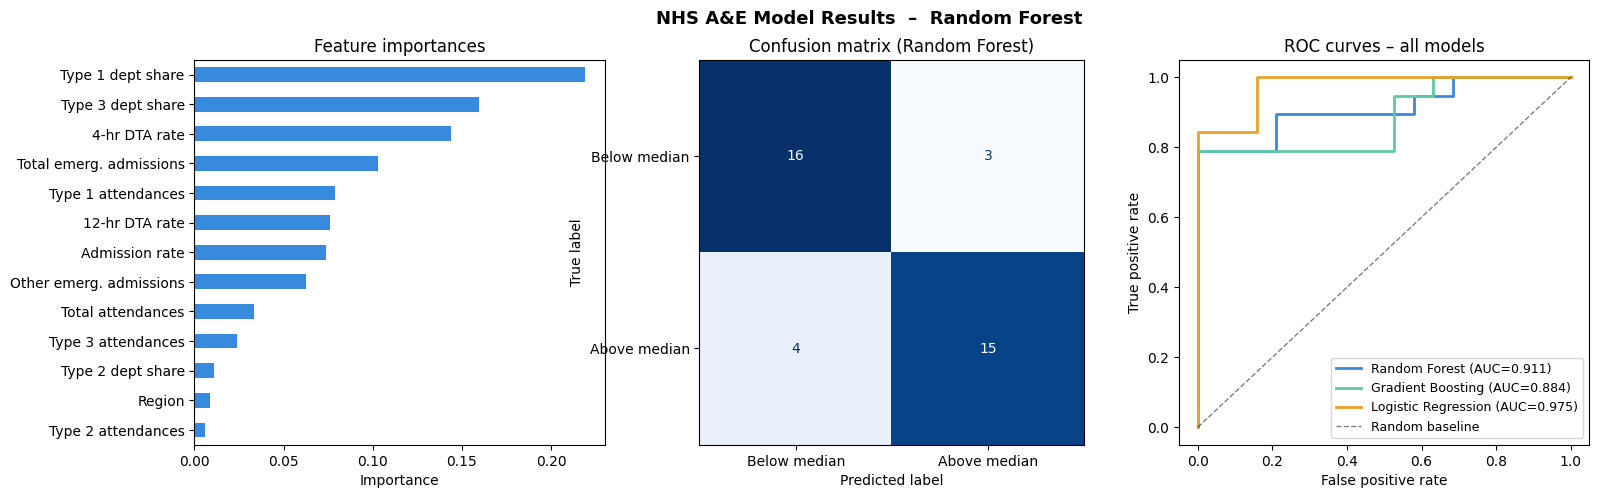

In [8]:
print("Generating model plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("NHS A&E Model Results  –  Random Forest", fontsize=13, fontweight="bold")

# Plot A: Feature importances
ax = axes[0]
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fi_labels = {
    "total_attendances":       "Total attendances",
    "type1_attendances":       "Type 1 attendances",
    "type2_attendances":       "Type 2 attendances",
    "type3_attendances":       "Type 3 attendances",
    "admission_rate":          "Admission rate",
    "t1_share":                "Type 1 dept share",
    "t2_share":                "Type 2 dept share",
    "t3_share":                "Type 3 dept share",
    "dta_4h_rate":             "4-hr DTA rate",
    "dta_12h_rate":            "12-hr DTA rate",
    "total_emerg_admissions":  "Total emerg. admissions",
    "other_emerg_admissions":  "Other emerg. admissions",
    "region_enc":              "Region",
}
fi.index = [fi_labels.get(i, i) for i in fi.index]
fi.plot(kind="barh", ax=ax, color=palette_blue, edgecolor="none")
ax.set_title("Feature importances")
ax.set_xlabel("Importance")

# Plot B: Confusion matrix (RF)
ax = axes[1]
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Below median", "Above median"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix (Random Forest)")

# Plot C: ROC curves (all 3 models)
ax = axes[2]
from sklearn.metrics import roc_curve
for (name, (pred, prob, _)), color in zip(models.items(),
                                           [palette_blue, palette_good, palette_warn]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves – all models")
ax.legend(fontsize=9)


### 8. SAVE PREDICTIONS


In [9]:
 # Use best-performing model (Logistic Regression by CV AUC) for final predictions
# Re-scale full dataset and predict
scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X)
lr_full = LogisticRegression(max_iter=1000, random_state=42)
lr_full.fit(X_full_s, y)

df_model = df_model.copy()
df_model["predicted_class"]            = lr_full.predict(X_full_s)
df_model["predicted_prob_above_median"] = lr_full.predict_proba(X_full_s)[:, 1]
df_model["predicted_label"]            = df_model["predicted_class"].map(
    {1: "Above median", 0: "Below median"}
)

output_cols = [
    "Code", "Region", "Name",
    "total_attendances", "pct_within_4h_all",
    "admission_rate", "t1_share", "t3_share",
    "dta_4h_rate", "dta_12h_rate",
    "target", "predicted_class",
    "predicted_prob_above_median", "predicted_label",
]
df_model[output_cols].to_csv(DATA_DIR + "AE_model_predictions.csv", index=False)
print("\nPredictions saved → AE_model_predictions.csv")
print("\nDone! ✅")


Predictions saved → AE_model_predictions.csv

Done! ✅


# THE END